# 03 — Machine-Learning Model Development

This notebook develops and evaluates classical machine-learning models for **one-month-ahead UK house-price forecasting**.

The evaluation design is deliberately stricter than a random train/test split:

- **training period** — used for model fitting and time-series cross-validation;
- **validation period** — used to compare candidate model families;
- **final test period** — kept untouched until the preferred model and hyperparameters have been selected.

The notebook also compares every model against simple forecasting baselines. A complex model is useful only if it can outperform a credible baseline under chronological evaluation.

## 1. Imports and project paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "data" / "processed" / "uk_housing_modelling_base.csv"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Project root:", PROJECT_ROOT)
print("Modelling dataset:", MODEL_PATH)

Project root: /mnt/data/ml_project
Modelling dataset: /mnt/data/ml_project/data/processed/uk_housing_modelling_base.csv


## 2. Load the leakage-aware modelling table

Notebook 01 created this table so that each row uses information available no later than the forecast origin and predicts the following month's average UK house price.

In [2]:
df = pd.read_csv(
    MODEL_PATH,
    parse_dates=["forecast_origin", "target_date"],
)

TARGET = "target_house_price_next_month_gbp"

assert len(df) == 160
assert df["forecast_origin"].is_monotonic_increasing
assert df["target_date"].is_monotonic_increasing
assert not df.isna().any().any()

print(f"Rows: {len(df)}")
print(f"Forecast targets: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
df.head()

Rows: 160
Forecast targets: 2010-01-01 to 2023-04-01


,forecast_origin,target_date,target_house_price_next_month_gbp,house_price_lag_1m_gbp,house_price_lag_3m_gbp,house_price_lag_12m_gbp,house_price_rolling_3m_mean_gbp,house_price_rolling_12m_mean_gbp,sales_volume_lag_1m,average_weekly_earnings_lag_1m_gbp,unemployment_rate_lag_1m_pct,cpi_annual_rate_lag_1m_pct,gdp_monthly_growth_lag_1m_pct,public_sector_net_borrowing_lag_1m_gbp_mn,bank_rate_lag_1m_pct,target_month_sin,target_month_cos
0,2009-12-01,2010-01-01,"167,468.930","168,081.609","166,424.903","157,233.924","167,164.220","161,148.033","87,202.000",440.000,7.700,2.900,0.500,"21,331.000",0.500,0.500,0.866
1,2010-01-01,2010-02-01,"167,887.682","167,468.930","166,986.149","155,417.385","167,512.229","162,000.950","41,084.667",439.000,7.900,3.500,-0.800,"7,697.000",0.500,0.866,0.500
2,2010-02-01,2010-03-01,"167,877.951","167,887.682","168,081.609","154,452.381","167,812.740","163,040.141","47,347.667",446.000,8.000,3.000,1.700,"9,831.000",0.500,1.000,0.000
3,2010-03-01,2010-04-01,"170,027.890","167,877.951","167,468.930","155,852.156","167,744.854","164,158.939","58,046.667",441.000,8.000,3.400,0.800,"13,191.000",0.500,0.866,-0.500
4,2010-04-01,2010-05-01,"170,845.925","170,027.890","167,887.682","158,004.466","168,597.841","165,340.250","59,554.667",441.000,7.900,3.700,-0.200,"9,201.000",0.500,0.500,-0.866


## 3. Define feature sets

Two feature sets are compared.

### Autoregressive feature set
Uses only historical house-price information plus calendar seasonality.

### Full feature set
Adds the lagged macroeconomic and housing-market indicators prepared in Notebook 01.

This separation allows an **ablation-style comparison**: do the external economic indicators improve a strong price-history model at a one-month horizon?

In [3]:
AUTOREGRESSIVE_FEATURES = [
    "house_price_lag_1m_gbp",
    "house_price_lag_3m_gbp",
    "house_price_lag_12m_gbp",
    "house_price_rolling_3m_mean_gbp",
    "house_price_rolling_12m_mean_gbp",
    "target_month_sin",
    "target_month_cos",
]

FULL_FEATURES = [
    c for c in df.columns
    if c not in ["forecast_origin", "target_date", TARGET]
]

print("Autoregressive features:", len(AUTOREGRESSIVE_FEATURES))
print("Full features:", len(FULL_FEATURES))

Autoregressive features: 7
Full features: 14


## 4. Chronological train / validation / test design

The final 48 observations are divided into two 24-month blocks:

- **Training:** January 2010 to April 2019 targets
- **Validation:** May 2019 to April 2021 targets
- **Final test:** May 2021 to April 2023 targets

The final test period is not used for hyperparameter tuning or candidate-model selection.

Within the training period, `TimeSeriesSplit` preserves chronology during cross-validation.

In [4]:
train = df.iloc[:-48].copy()
validation = df.iloc[-48:-24].copy()
test = df.iloc[-24:].copy()

assert len(train) == 112
assert len(validation) == 24
assert len(test) == 24

split_summary = pd.DataFrame({
    "split": ["Training", "Validation", "Final test"],
    "rows": [len(train), len(validation), len(test)],
    "target_start": [
        train["target_date"].min().date(),
        validation["target_date"].min().date(),
        test["target_date"].min().date(),
    ],
    "target_end": [
        train["target_date"].max().date(),
        validation["target_date"].max().date(),
        test["target_date"].max().date(),
    ],
})

split_summary

,split,rows,target_start,target_end
0,Training,112,2010-01-01,2019-04-01
1,Validation,24,2019-05-01,2021-04-01
2,Final test,24,2021-05-01,2023-04-01


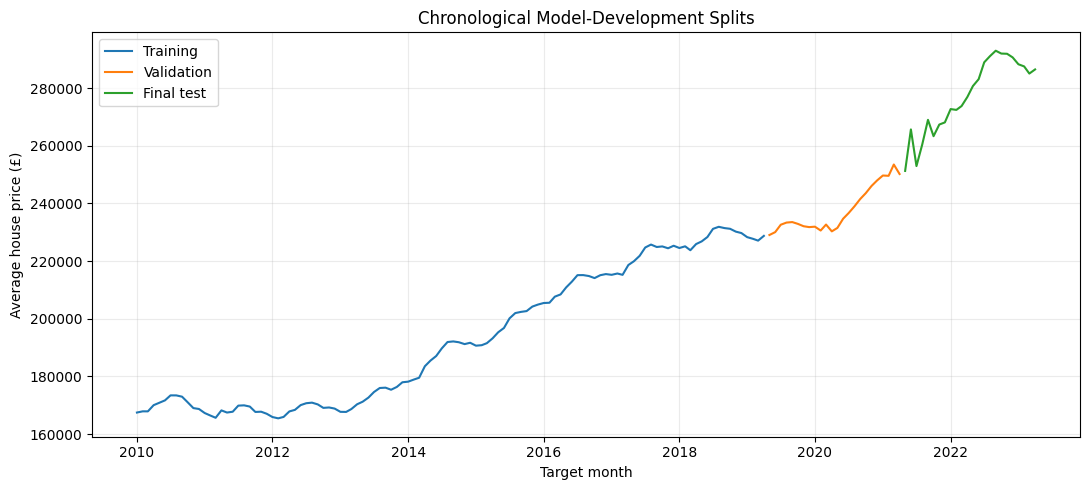

In [5]:
plt.figure(figsize=(11, 5))
plt.plot(train["target_date"], train[TARGET], label="Training")
plt.plot(validation["target_date"], validation[TARGET], label="Validation")
plt.plot(test["target_date"], test[TARGET], label="Final test")
plt.title("Chronological Model-Development Splits")
plt.xlabel("Target month")
plt.ylabel("Average house price (£)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Evaluation metrics

Four metrics are reported:

- **MAE** — average absolute prediction error in pounds;
- **RMSE** — penalises larger errors more strongly;
- **MAPE** — average percentage error;
- **R²** — proportion of variance explained within the evaluation window.

RMSE is used as the primary tuning metric.

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_pct": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }

## 6. Forecasting baselines

Three simple baselines are included.

1. **Persistence:** next month's price equals the latest observed price.
2. **Annual drift:** extends the average recent annual price direction one month forward.
3. **12-month seasonal baseline:** uses the comparable historical price from twelve months before the target.

These are intentionally simple but important. A machine-learning model should demonstrate value beyond them.

In [7]:
def baseline_predictions(frame):
    current = frame["house_price_lag_1m_gbp"].to_numpy()
    lag_12 = frame["house_price_lag_12m_gbp"].to_numpy()

    persistence = current
    annual_drift = current + (current - lag_12) / 11
    seasonal_12m = lag_12

    return {
        "Persistence baseline": persistence,
        "Annual-drift baseline": annual_drift,
        "12-month seasonal baseline": seasonal_12m,
    }

baseline_validation_rows = []

for name, pred in baseline_predictions(validation).items():
    metrics = regression_metrics(validation[TARGET], pred)
    baseline_validation_rows.append({
        "model": name,
        **metrics,
    })

pd.DataFrame(baseline_validation_rows).sort_values("RMSE")

,model,MAE,RMSE,MAPE_pct,R2
1,Annual-drift baseline,"1,515.638","1,919.037",0.633,0.937
0,Persistence baseline,"1,630.857","1,954.083",0.680,0.935
2,12-month seasonal baseline,"7,135.521","9,783.625",2.919,-0.625


## 7. Time-series cross-validation and candidate models

Hyperparameters are tuned **only inside the training period** using expanding-window time-series cross-validation.

The candidate set includes:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Gradient Boosting

The linear models are evaluated with both autoregressive and full feature sets where appropriate. Tree ensembles use the full feature set.

The grids are deliberately compact because the dataset is small; the aim is robust model comparison rather than an excessively large search.

In [8]:
tscv = TimeSeriesSplit(n_splits=4)

CANDIDATES = {
    "AR Linear Regression": {
        "features": AUTOREGRESSIVE_FEATURES,
        "estimator": Pipeline([
            ("scale", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "param_grid": None,
    },
    "AR Ridge Regression": {
        "features": AUTOREGRESSIVE_FEATURES,
        "estimator": Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge()),
        ]),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1, 10, 100],
        },
    },
    "AR Lasso Regression": {
        "features": AUTOREGRESSIVE_FEATURES,
        "estimator": Pipeline([
            ("scale", StandardScaler()),
            ("model", Lasso(max_iter=50_000)),
        ]),
        "param_grid": {
            "model__alpha": [10, 50, 100, 250, 500],
        },
    },
    "Full Ridge Regression": {
        "features": FULL_FEATURES,
        "estimator": Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge()),
        ]),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1, 10, 100],
        },
    },
    "Full Lasso Regression": {
        "features": FULL_FEATURES,
        "estimator": Pipeline([
            ("scale", StandardScaler()),
            ("model", Lasso(max_iter=50_000)),
        ]),
        "param_grid": {
            "model__alpha": [10, 50, 100, 250, 500],
        },
    },
    "Full Random Forest": {
        "features": FULL_FEATURES,
        "estimator": RandomForestRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [4, 8],
            "min_samples_leaf": [1, 3],
        },
    },
    "Full Gradient Boosting": {
        "features": FULL_FEATURES,
        "estimator": GradientBoostingRegressor(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.03, 0.05],
            "max_depth": [1, 2],
        },
    },
}

In [9]:
def time_series_cv_rmse(estimator, X, y, splitter):
    fold_rmse = []

    for train_idx, valid_idx in splitter.split(X):
        model = clone(estimator)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[valid_idx])
        fold_rmse.append(
            mean_squared_error(y.iloc[valid_idx], pred) ** 0.5
        )

    return float(np.mean(fold_rmse)), float(np.std(fold_rmse))

## 8. Tune candidates on training data and evaluate on validation data

The validation period is used to select the preferred classical machine-learning model. The final test period remains untouched at this stage.

In [10]:
validation_results = []
fitted_candidates = {}

for name, config in CANDIDATES.items():
    features = config["features"]
    estimator = config["estimator"]
    param_grid = config["param_grid"]

    X_train = train[features]
    y_train = train[TARGET]

    if param_grid is None:
        cv_mean, cv_std = time_series_cv_rmse(
            estimator,
            X_train,
            y_train,
            tscv,
        )
        best_model = clone(estimator).fit(X_train, y_train)
        best_params = {}
    else:
        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=1,
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        cv_mean = -search.best_score_
        cv_std = search.cv_results_["std_test_score"][search.best_index_]
        best_params = search.best_params_

    validation_pred = best_model.predict(validation[features])
    metrics = regression_metrics(validation[TARGET], validation_pred)

    validation_results.append({
        "model": name,
        "feature_set": (
            "Autoregressive"
            if features == AUTOREGRESSIVE_FEATURES
            else "Full"
        ),
        "CV_RMSE_mean": cv_mean,
        "CV_RMSE_std": cv_std,
        **metrics,
        "best_params": str(best_params),
    })

    fitted_candidates[name] = {
        "model": best_model,
        "features": features,
        "best_params": best_params,
    }

validation_results = pd.DataFrame(validation_results)
validation_results.sort_values("RMSE")

,model,feature_set,CV_RMSE_mean,CV_RMSE_std,MAE,RMSE,MAPE_pct,R2,best_params
2,AR Lasso Regression,Autoregressive,"1,351.829",265.276,"1,451.903","1,890.397",0.603,0.939,{'model__alpha': 10}
0,AR Linear Regression,Autoregressive,"1,583.065",279.271,"1,408.328","1,951.276",0.586,0.935,{}
1,AR Ridge Regression,Autoregressive,"1,448.132",215.338,"1,578.387","2,026.207",0.655,0.930,{'model__alpha': 0.1}
4,Full Lasso Regression,Full,"1,707.531",611.609,"2,150.010","2,698.690",0.888,0.876,{'model__alpha': 10}
3,Full Ridge Regression,Full,"1,650.773",505.266,"2,508.425","3,215.954",1.035,0.824,{'model__alpha': 0.1}
6,Full Gradient Boosting,Full,"9,267.702","5,183.354","8,397.432","12,065.472",3.422,-1.471,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
5,Full Random Forest,Full,"9,824.960","5,351.253","10,127.230","13,945.693",4.138,-2.302,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_est..."


## 9. Compare candidate models with the baselines

In [11]:
baseline_table = pd.DataFrame(baseline_validation_rows).assign(
    feature_set="Baseline",
    CV_RMSE_mean=np.nan,
    CV_RMSE_std=np.nan,
    best_params="",
)

comparison_columns = [
    "model",
    "feature_set",
    "CV_RMSE_mean",
    "CV_RMSE_std",
    "MAE",
    "RMSE",
    "MAPE_pct",
    "R2",
    "best_params",
]

validation_comparison = pd.concat([
    validation_results[comparison_columns],
    baseline_table[comparison_columns],
], ignore_index=True)

validation_comparison.sort_values("RMSE")

,model,feature_set,CV_RMSE_mean,CV_RMSE_std,MAE,RMSE,MAPE_pct,R2,best_params
2,AR Lasso Regression,Autoregressive,"1,351.829",265.276,"1,451.903","1,890.397",0.603,0.939,{'model__alpha': 10}
8,Annual-drift baseline,Baseline,NaN,NaN,"1,515.638","1,919.037",0.633,0.937,
0,AR Linear Regression,Autoregressive,"1,583.065",279.271,"1,408.328","1,951.276",0.586,0.935,{}
7,Persistence baseline,Baseline,NaN,NaN,"1,630.857","1,954.083",0.680,0.935,
1,AR Ridge Regression,Autoregressive,"1,448.132",215.338,"1,578.387","2,026.207",0.655,0.930,{'model__alpha': 0.1}
4,Full Lasso Regression,Full,"1,707.531",611.609,"2,150.010","2,698.690",0.888,0.876,{'model__alpha': 10}
3,Full Ridge Regression,Full,"1,650.773",505.266,"2,508.425","3,215.954",1.035,0.824,{'model__alpha': 0.1}
9,12-month seasonal baseline,Baseline,NaN,NaN,"7,135.521","9,783.625",2.919,-0.625,
6,Full Gradient Boosting,Full,"9,267.702","5,183.354","8,397.432","12,065.472",3.422,-1.471,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
5,Full Random Forest,Full,"9,824.960","5,351.253","10,127.230","13,945.693",4.138,-2.302,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_est..."


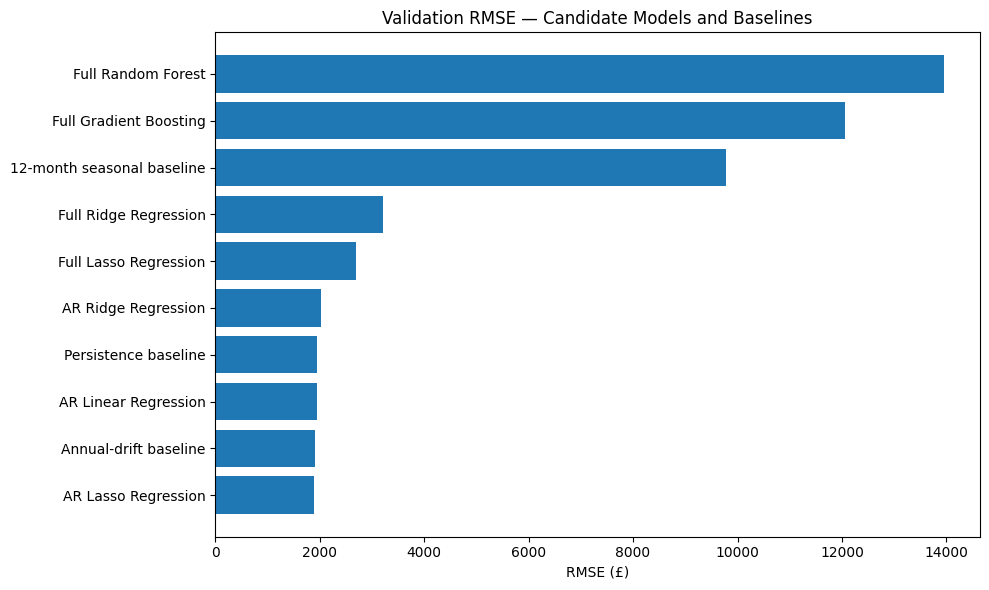

In [12]:
plot_data = validation_comparison.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["model"], plot_data["RMSE"])
plt.title("Validation RMSE — Candidate Models and Baselines")
plt.xlabel("RMSE (£)")
plt.tight_layout()
plt.show()

### Validation interpretation

The validation window is the model-selection stage. The preferred classical model is selected here **before the final test period is opened**.

A particularly important comparison is between the autoregressive models and the full-feature models. If adding macroeconomic variables worsens out-of-time performance, the responsible decision is to retain the simpler specification rather than forcing additional features into the final model.

In [13]:
preferred_row = (
    validation_results
    .sort_values("RMSE")
    .iloc[0]
)

PREFERRED_MODEL_NAME = preferred_row["model"]
PREFERRED_PARAMS = fitted_candidates[PREFERRED_MODEL_NAME]["best_params"]
PREFERRED_FEATURES = fitted_candidates[PREFERRED_MODEL_NAME]["features"]

print("Preferred classical model:", PREFERRED_MODEL_NAME)
print("Selected hyperparameters:", PREFERRED_PARAMS)
print("Validation RMSE:", f"£{preferred_row['RMSE']:,.0f}")
print("Validation MAE:", f"£{preferred_row['MAE']:,.0f}")
print("Validation MAPE:", f"{preferred_row['MAPE_pct']:.2f}%")

Preferred classical model: AR Lasso Regression
Selected hyperparameters: {'model__alpha': 10}
Validation RMSE: £1,890
Validation MAE: £1,452
Validation MAPE: 0.60%


## 10. Feature-set ablation: do macroeconomic variables add value?

For the one-month horizon, compare regularised linear models using only price-history features against equivalent models using the full macroeconomic feature set.

In [14]:
ablation_models = [
    "AR Ridge Regression",
    "AR Lasso Regression",
    "Full Ridge Regression",
    "Full Lasso Regression",
]

validation_results[
    validation_results["model"].isin(ablation_models)
][[
    "model",
    "feature_set",
    "CV_RMSE_mean",
    "MAE",
    "RMSE",
    "MAPE_pct",
    "R2",
]].sort_values("RMSE")

,model,feature_set,CV_RMSE_mean,MAE,RMSE,MAPE_pct,R2
2,AR Lasso Regression,Autoregressive,"1,351.829","1,451.903","1,890.397",0.603,0.939
1,AR Ridge Regression,Autoregressive,"1,448.132","1,578.387","2,026.207",0.655,0.930
4,Full Lasso Regression,Full,"1,707.531","2,150.010","2,698.690",0.888,0.876
3,Full Ridge Regression,Full,"1,650.773","2,508.425","3,215.954",1.035,0.824


A macroeconomic variable can be economically relevant without improving a one-month-ahead statistical forecast. The ablation result should therefore be interpreted as a **forecast-horizon finding**, not as a claim that macroeconomic conditions do not affect the housing market.

## 11. Why tree ensembles can struggle in a chronological holdout

Random Forest and Gradient Boosting are powerful nonlinear methods, but standard tree regressors are weak at **extrapolating target levels beyond the range observed during training**.

This is especially relevant when the target is a strongly trending house-price level and the validation period contains higher price levels than the training period.

In [15]:
print(
    "Maximum target price in training:",
    f"£{train[TARGET].max():,.0f}"
)
print(
    "Maximum target price in validation:",
    f"£{validation[TARGET].max():,.0f}"
)

tree_rows = validation_results[
    validation_results["model"].isin([
        "Full Random Forest",
        "Full Gradient Boosting",
    ])
]

tree_rows[[
    "model",
    "CV_RMSE_mean",
    "MAE",
    "RMSE",
    "R2",
]]

Maximum target price in training: £231,898
Maximum target price in validation: £253,506


,model,CV_RMSE_mean,MAE,RMSE,R2
5,Full Random Forest,"9,824.960","10,127.230","13,945.693",-2.302
6,Full Gradient Boosting,"9,267.702","8,397.432","12,065.472",-1.471


## 12. Refit the selected model on training + validation data

After model family and hyperparameters have been fixed using the validation stage, the selected model is refitted using all development data available before the final test period.

No hyperparameter changes are made after viewing the final test results.

In [16]:
development = pd.concat([train, validation], ignore_index=True)

selected_config = CANDIDATES[PREFERRED_MODEL_NAME]
final_model = clone(selected_config["estimator"])

if PREFERRED_PARAMS:
    final_model.set_params(**PREFERRED_PARAMS)

final_model.fit(
    development[PREFERRED_FEATURES],
    development[TARGET],
)

print(
    "Development target period:",
    development["target_date"].min().date(),
    "to",
    development["target_date"].max().date(),
)
print(
    "Final test target period:",
    test["target_date"].min().date(),
    "to",
    test["target_date"].max().date(),
)

Development target period: 2010-01-01 to 2021-04-01
Final test target period: 2021-05-01 to 2023-04-01


## 13. Final untouched test evaluation

In [17]:
final_pred = final_model.predict(test[PREFERRED_FEATURES])
final_metrics = regression_metrics(test[TARGET], final_pred)

final_baselines = baseline_predictions(test)

final_comparison_rows = [{
    "model": PREFERRED_MODEL_NAME,
    **final_metrics,
}]

for name, pred in final_baselines.items():
    final_comparison_rows.append({
        "model": name,
        **regression_metrics(test[TARGET], pred),
    })

final_comparison = pd.DataFrame(final_comparison_rows)
final_comparison.sort_values("RMSE")

,model,MAE,RMSE,MAPE_pct,R2
0,AR Lasso Regression,"3,255.293","4,955.843",1.213,0.844
2,Annual-drift baseline,"3,596.561","5,215.396",1.332,0.828
1,Persistence baseline,"3,727.899","5,247.147",1.381,0.826
3,12-month seasonal baseline,"22,282.344","23,148.002",8.042,-2.394


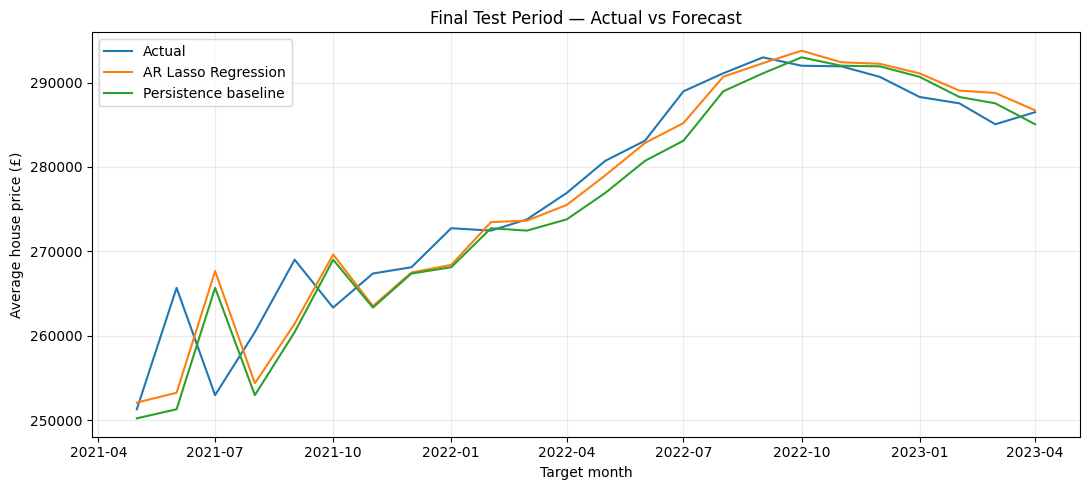

In [18]:
plt.figure(figsize=(11, 5))
plt.plot(test["target_date"], test[TARGET], label="Actual")
plt.plot(test["target_date"], final_pred, label=PREFERRED_MODEL_NAME)
plt.plot(
    test["target_date"],
    final_baselines["Persistence baseline"],
    label="Persistence baseline",
)
plt.title("Final Test Period — Actual vs Forecast")
plt.xlabel("Target month")
plt.ylabel("Average house price (£)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 14. Final-test residual analysis

Residuals are defined as:

**actual price − predicted price**

Positive residuals indicate underprediction; negative residuals indicate overprediction.

In [19]:
final_predictions = pd.DataFrame({
    "target_date": test["target_date"].to_numpy(),
    "actual_gbp": test[TARGET].to_numpy(),
    "predicted_gbp": final_pred,
})

final_predictions["residual_gbp"] = (
    final_predictions["actual_gbp"]
    - final_predictions["predicted_gbp"]
)

final_predictions["absolute_error_gbp"] = final_predictions["residual_gbp"].abs()
final_predictions["absolute_percentage_error"] = (
    final_predictions["absolute_error_gbp"]
    / final_predictions["actual_gbp"]
    * 100
)

final_predictions.head()

,target_date,actual_gbp,predicted_gbp,residual_gbp,absolute_error_gbp,absolute_percentage_error
0,2021-05-01,"251,285.480","252,077.642",-792.161,792.161,0.315
1,2021-06-01,"265,676.075","253,244.563","12,431.512","12,431.512",4.679
2,2021-07-01,"252,960.133","267,655.404","-14,695.271","14,695.271",5.809
3,2021-08-01,"260,429.179","254,369.901","6,059.278","6,059.278",2.327
4,2021-09-01,"269,003.075","261,425.147","7,577.928","7,577.928",2.817


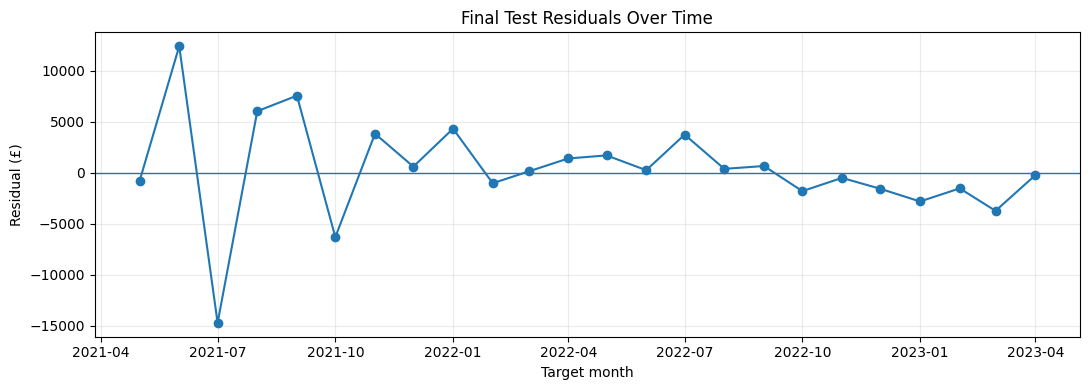

In [20]:
plt.figure(figsize=(11, 4))
plt.plot(
    final_predictions["target_date"],
    final_predictions["residual_gbp"],
    marker="o",
)
plt.axhline(0, linewidth=1)
plt.title("Final Test Residuals Over Time")
plt.xlabel("Target month")
plt.ylabel("Residual (£)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
final_predictions.sort_values(
    "absolute_error_gbp",
    ascending=False,
).head(10)

,target_date,actual_gbp,predicted_gbp,residual_gbp,absolute_error_gbp,absolute_percentage_error
2,2021-07-01,"252,960.133","267,655.404","-14,695.271","14,695.271",5.809
1,2021-06-01,"265,676.075","253,244.563","12,431.512","12,431.512",4.679
4,2021-09-01,"269,003.075","261,425.147","7,577.928","7,577.928",2.817
5,2021-10-01,"263,333.230","269,620.002","-6,286.772","6,286.772",2.387
3,2021-08-01,"260,429.179","254,369.901","6,059.278","6,059.278",2.327
8,2022-01-01,"272,738.317","268,395.463","4,342.854","4,342.854",1.592
6,2021-11-01,"267,369.958","263,518.173","3,851.785","3,851.785",1.441
14,2022-07-01,"288,960.850","285,200.669","3,760.180","3,760.180",1.301
22,2023-03-01,"285,056.727","288,769.142","-3,712.414","3,712.414",1.302
20,2023-01-01,"288,288.610","291,080.654","-2,792.044","2,792.044",0.968


## 15. Interpret the selected regularised model

For a scaled Lasso or Ridge pipeline, coefficient magnitude can be compared because the predictors were standardised before fitting.

If Lasso is selected, zero coefficients indicate features removed by the regularisation process.

In [22]:
if hasattr(final_model, "named_steps") and "model" in final_model.named_steps:
    estimator = final_model.named_steps["model"]

    if hasattr(estimator, "coef_"):
        coefficient_table = pd.DataFrame({
            "feature": PREFERRED_FEATURES,
            "standardised_coefficient": estimator.coef_,
        })
        coefficient_table["absolute_coefficient"] = (
            coefficient_table["standardised_coefficient"].abs()
        )

        coefficient_table = coefficient_table.sort_values(
            "absolute_coefficient",
            ascending=False,
        )

        display(coefficient_table)

        non_zero = (
            coefficient_table["standardised_coefficient"].abs() > 1e-12
        ).sum()

        print(
            f"Non-zero coefficients: {non_zero} "
            f"of {len(coefficient_table)}"
        )
    else:
        print("The selected estimator does not expose linear coefficients.")
else:
    print("The selected estimator is not a scaled linear pipeline.")

,feature,standardised_coefficient,absolute_coefficient
0,house_price_lag_1m_gbp,"27,634.833","27,634.833"
6,target_month_cos,-686.002,686.002
2,house_price_lag_12m_gbp,-201.846,201.846
5,target_month_sin,41.840,41.840
1,house_price_lag_3m_gbp,-0.000,0.000
4,house_price_rolling_12m_mean_gbp,-0.000,0.000
3,house_price_rolling_3m_mean_gbp,0.000,0.000


Non-zero coefficients: 4 of 7


## 16. Modelling conclusions

This notebook uses a deliberately conservative workflow:

1. The target is forecast **one month ahead** using only information available at the forecast origin.
2. All observations remain in chronological order.
3. Hyperparameter tuning uses expanding-window time-series cross-validation within the training period.
4. A separate validation window is used to choose the preferred classical model.
5. The final 24 months remain untouched until model choice and hyperparameters are fixed.
6. Simple persistence and drift baselines are treated as serious competitors.
7. Autoregressive and full macroeconomic feature sets are compared explicitly.
8. Poor out-of-time tree-model performance is retained and explained rather than hidden.

The results show that recent house-price history is the dominant signal for this one-month forecasting task. Adding the full macroeconomic feature set does not automatically improve out-of-time accuracy, and nonlinear tree ensembles struggle to extrapolate a rising target level.

The preferred classical model improves on the simple persistence baseline on the final test period. The next notebook will evaluate an **Artificial Neural Network** under the same chronological framework so that deep learning is compared fairly against both the classical model and the forecasting baselines.